In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
df = pd.read_csv("train.csv")
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

El dataset tiene 891 filas y 12 columnas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Información sobre los datos
print("=== INFORMACIÓN GENERAL ===")
df.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)


=== TIPOS DE DATOS ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [5]:
print("\n=== DESCRIPCIÓN DE LOS DATOS ===")
print(df.describe(include="all"))


=== DESCRIPCIÓN DE LOS DATOS ===
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibS

In [6]:
print("\n=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())


=== VALORES NULOS POR COLUMNA ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
# Rellenar la edad con la mediana para limpiar los valores nulos de la columna Age:
# La edad es una variable numérica continua, por lo que tiene sentido rellenarla con un 
# valor representativo como la mediana. Si fuera una variable categórica, podríamos considerar 
# rellenarla con la moda. Como se podrá observar más adelante, la distribución de edades es 
# asimétrica, con una cola larga hacia la derecha, lo que refuerza la elección de la mediana 
# como medida de tendencia central más adecuada para rellenar los valores nulos.
# Además, no hay mucha diferencia entre la media y la mediana.
print(f"La media de edad es {df['Age'].mean()}")
print(f"La mediana de edad es: {df['Age'].median()}")
df.fillna({'Age': df['Age'].median()}, inplace=True)

# Eliminar la columna Cabin porque tiene demasiados nulos
df.drop(columns=["Cabin"], inplace=True)

# Eliminar las 2 filas donde falta Embarked
df.dropna(subset=["Embarked"], inplace=True)

print(f"\nLimpieza completada. Nulos restantes: {df.isnull().sum().sum()}")
print(f"Ahora el dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")

La media de edad es 29.69911764705882
La mediana de edad es: 28.0

Limpieza completada. Nulos restantes: 0
Ahora el dataset tiene 889 filas y 11 columnas


In [8]:
# Comprobar datos no numéricos en columnas numéricas
print("=== VERIFICACIÓN DE COLUMNAS NUMÉRICAS ===\n")

# Columnas numéricas esperadas
numeric_columns = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

for col in numeric_columns:
    if col in df.columns:
        # Intentar convertir a numérico y ver qué values fallan
        non_numeric = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
        
        if non_numeric.any():
            print(f"❌ {col}: {non_numeric.sum()} valores no numéricos encontrados")
            print(f"   Ejemplos: {df[non_numeric][col].unique()[:5]}")
        else:
            print(f"✅ {col}: Todos los valores son numéricos")

=== VERIFICACIÓN DE COLUMNAS NUMÉRICAS ===

✅ PassengerId: Todos los valores son numéricos
✅ Survived: Todos los valores son numéricos
✅ Pclass: Todos los valores son numéricos
✅ Age: Todos los valores son numéricos
✅ SibSp: Todos los valores son numéricos
✅ Parch: Todos los valores son numéricos
✅ Fare: Todos los valores son numéricos


In [9]:
# Verificación de valores negativos en columnas numéricas
print("=== VERIFICACIÓN DE VALORES NEGATIVOS ===\n")

# Columnas numéricas que no deberían tener valores negativos
numeric_columns = ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

for col in numeric_columns:
    if col in df.columns:
        negative_count = (df[col] < 0).sum()
        
        if negative_count > 0:
            print(f"❌ {col}: {negative_count} valores negativos encontrados")
            print(f"   Rango: {df[df[col] < 0][col].min()} a {df[df[col] < 0][col].max()}")
            print(f"   Ejemplos: {df[df[col] < 0][col].unique()[:5]}\n")
        else:
            print(f"✅ {col}: Sin valores negativos (min: {df[col].min()})")

=== VERIFICACIÓN DE VALORES NEGATIVOS ===

✅ PassengerId: Sin valores negativos (min: 1)
✅ Survived: Sin valores negativos (min: 0)
✅ Pclass: Sin valores negativos (min: 1)
✅ Age: Sin valores negativos (min: 0.42)
✅ SibSp: Sin valores negativos (min: 0)
✅ Parch: Sin valores negativos (min: 0)
✅ Fare: Sin valores negativos (min: 0.0)


La columna Sex puede tener estos valores: Sex
male      577
female    312
Name: count, dtype: int64


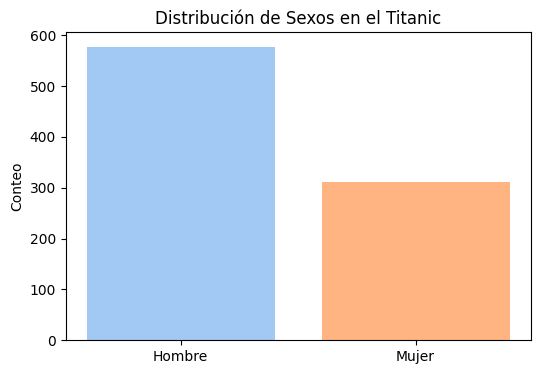

In [10]:
# Comprobar valores únicos para la columna Sex
print(f"La columna Sex puede tener estos valores: {df['Sex'].value_counts()}")

# Visualizamos la distribución de mujeres y hombres
counts = df['Sex'].value_counts()
colors = sns.color_palette('pastel', n_colors=len(counts))

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)
plt.xticks(counts.index, ['Hombre', 'Mujer'])
plt.ylabel('Conteo')
plt.title('Distribución de Sexos en el Titanic')
plt.show()

La columna Survived puede tener estos valores: Survived
0    549
1    340
Name: count, dtype: int64



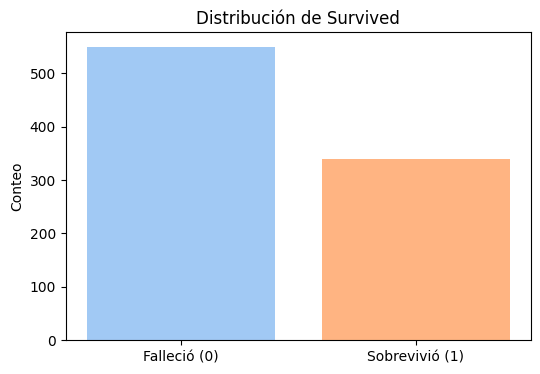

In [11]:
# Comprobación de valores únicos para la columna Survived
# Sabemos que solo puede tener dos valores: 0 (no superviviente) o 1 (superviviente)
# Además, hubo más fallecidos que supervivientes
print(f"La columna Survived puede tener estos valores: {df['Survived'].value_counts()}\n")

#Ahora visualizamos la distribución de supervivientes y fallecidos
counts = df['Survived'].value_counts()
colors = sns.color_palette('pastel', n_colors=len(counts))

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)
plt.xticks([0,1], ['Falleció (0)', 'Sobrevivió (1)'])
plt.ylabel('Conteo')
plt.title('Distribución de Survived')
plt.show()

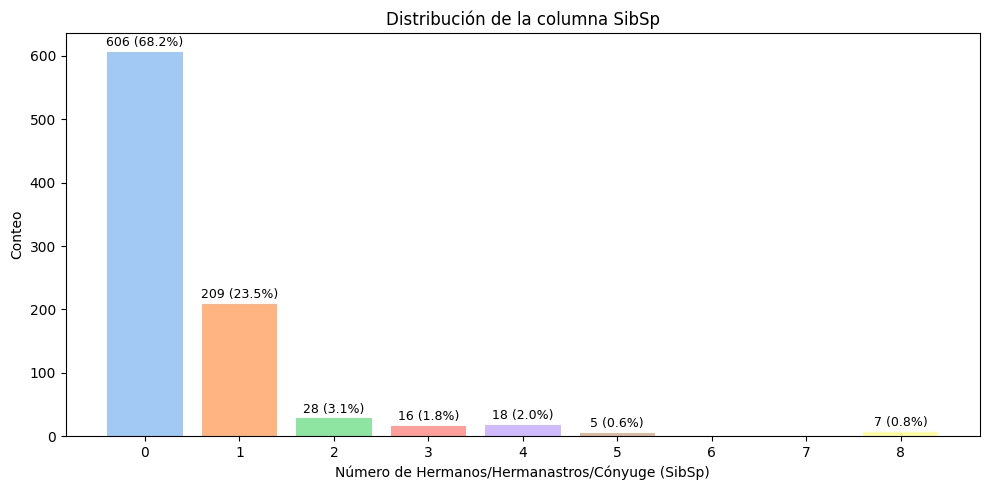

In [12]:
# Distribución de los datos en la columna SibSp que define el número de hermanos/cónyuges/hermanastros/as a bordo

counts = df['SibSp'].value_counts().sort_index()
total = counts.sum()

# Crear rango completo de 0 a max, rellenando con 0 los valores que faltan
full_range = range(int(counts.index.min()), int(counts.index.max()) + 1)
counts_full = counts.reindex(full_range, fill_value=0)

plt.figure(figsize=(10, 5))
colors = sns.color_palette('pastel', n_colors=len(counts_full))
plt.bar(counts_full.index, counts_full.values, color=colors)

for i, v in enumerate(counts_full.values):
    if v > 0:
        pct = v/total*100
        plt.text(i, v + total*0.01, f"{v} ({pct:.1f}%)", ha='center', fontsize=9)

plt.xticks(counts_full.index)
plt.xlabel('Número de Hermanos/Hermanastros/Cónyuge (SibSp)')
plt.ylabel('Conteo')
plt.title('Distribución de la columna SibSp')
plt.tight_layout()
plt.show()

La columna Pclass puede tener estos valores: Pclass
1    214
2    184
3    491
Name: count, dtype: int64



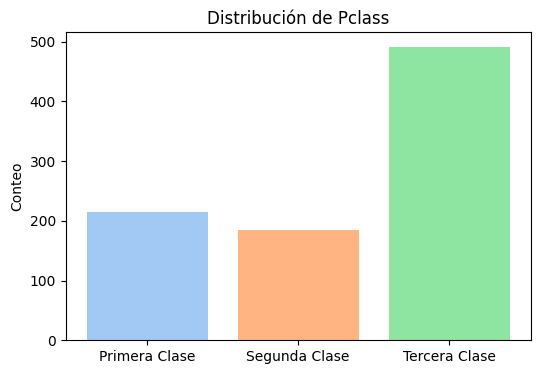

In [13]:
# Comprobación de valores únicos para la columna Pclass
# Sabemos que solo puede tener tres valores: 1 (primera clase), 2 (segunda clase) o 3 (tercera clase)
print(f"La columna Pclass puede tener estos valores: {df['Pclass'].value_counts().sort_index()}\n")

#Ahora visualizamos la distribución de Pclass
counts = df['Pclass'].value_counts().sort_index()   
colors = sns.color_palette('pastel', n_colors=len(counts))

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)
plt.xticks([1,2,3], ['Primera Clase', 'Segunda Clase', 'Tercera Clase'])
plt.ylabel('Conteo')
plt.title('Distribución de Pclass')
plt.show()

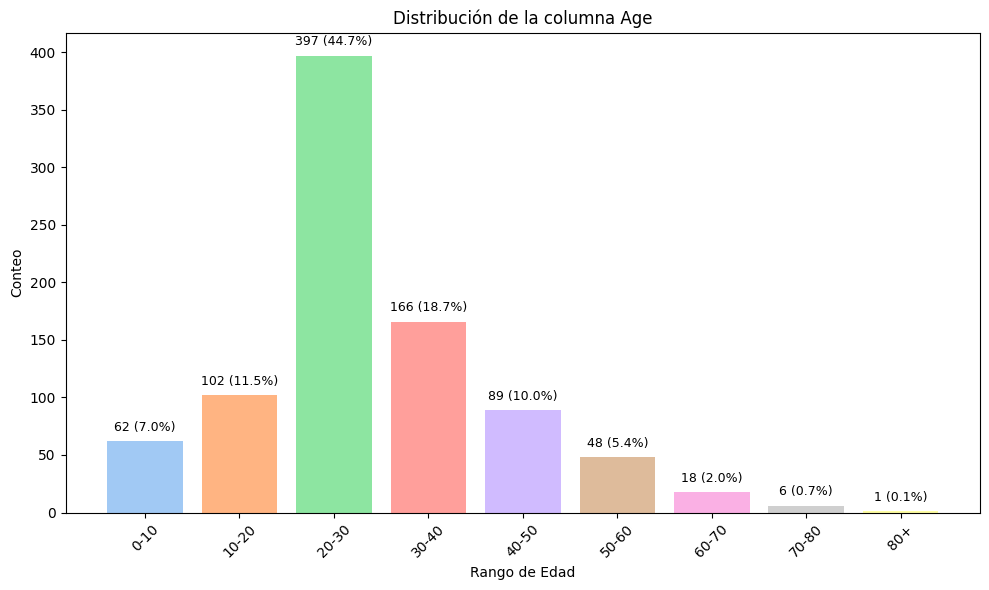

In [14]:
# Distribución de los datos en la columna Age 
# Agrupar las edades en rangos para mejor visualización
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']

counts = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False).value_counts().sort_index()
total = counts.sum()

plt.figure(figsize=(10, 6))
colors = sns.color_palette('pastel', n_colors=len(counts))
plt.bar(range(len(counts)), counts.values, color=colors)

for i, v in enumerate(counts.values):
    pct = v/total*100
    plt.text(i, v + total*0.01, f"{v} ({pct:.1f}%)", ha='center', fontsize=9)

plt.xticks(range(len(counts)), counts.index, rotation=45)
plt.xlabel('Rango de Edad')
plt.ylabel('Conteo')
plt.title('Distribución de la columna Age')
plt.tight_layout()
plt.show()

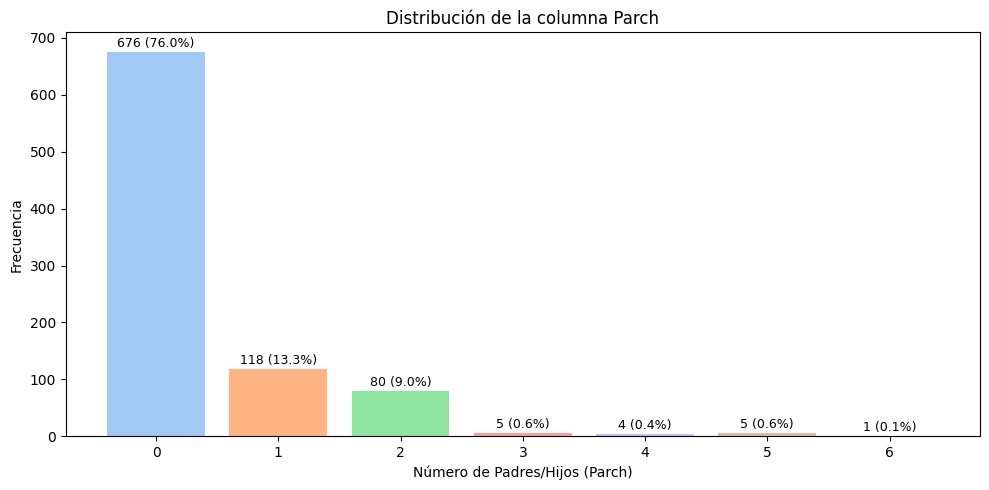

In [15]:
# Distribución de los datos en la columna Parch 
# Parch = Número de padres/hijos a bordo que viajan con cada pasajero
counts = df['Parch'].value_counts().sort_index()
total = counts.sum()

# Crear rango completo de 0 a max, rellenando con 0 los valores que faltan
full_range = range(int(counts.index.min()), int(counts.index.max()) + 1)
counts_full = counts.reindex(full_range, fill_value=0)

plt.figure(figsize=(10, 5))
colors = sns.color_palette('pastel', n_colors=len(counts_full))
plt.bar(counts_full.index, counts_full.values, color=colors)

for i, v in enumerate(counts_full.values):
    if v > 0:
        pct = v/total*100
        plt.text(i, v + total*0.01, f"{v} ({pct:.1f}%)", ha='center', fontsize=9)

plt.xticks(counts_full.index)
plt.xlabel('Número de Padres/Hijos (Parch)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la columna Parch')
plt.tight_layout()
plt.show()

La columna Embarked puede tener estos valores: Embarked
S    644
C    168
Q     77
Name: count, dtype: int64



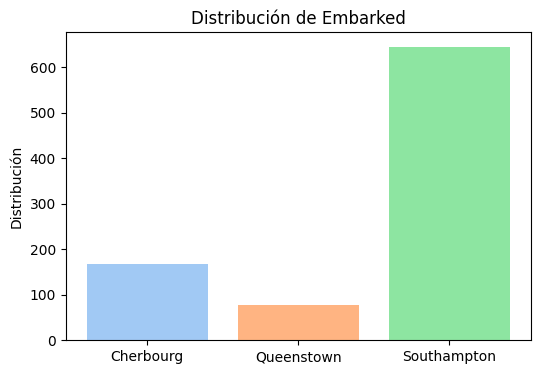

In [16]:
# Comprobación de valores únicos para la columna Embarked, que define el puerto de embarque de cada pasajero
# Sabemos que solo puede tener tres valores: C = Cherbourg, Q = Queenstown, S = Southampton
print(f"La columna Embarked puede tener estos valores: {df['Embarked'].value_counts()}\n")  

#Ahora visualizamos la distribución de Embarked
counts = df['Embarked'].value_counts().sort_index()   
colors = sns.color_palette('pastel', n_colors=len(counts))

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)
plt.xticks(counts.index, ['Cherbourg', 'Queenstown', 'Southampton'])
plt.ylabel('Distribución')
plt.title('Distribución de Embarked')
plt.show()

In [17]:
# Tasa de supervivencia general
tasa_general = df["Survived"].mean() * 100
print(f"Tasa de supervivencia general: {tasa_general:.1f}%")

# Por sexo
print("\nSupervivencia por sexo:")
print(df.groupby("Sex")["Survived"].mean().mul(100).round(1).astype(str) + "%")

# Por clase
print("\nSupervivencia por clase:")
print(df.groupby("Pclass")["Survived"].mean().mul(100).round(1).astype(str) + "%")

# Según el puerto de embarque
print("\nSupervivencia por puerto de embarque:")
print(df.groupby("Embarked")["Survived"].mean().mul(100).round(1).astype(str) + "%")


Tasa de supervivencia general: 38.2%

Supervivencia por sexo:
Sex
female    74.0%
male      18.9%
Name: Survived, dtype: str

Supervivencia por clase:
Pclass
1    62.6%
2    47.3%
3    24.2%
Name: Survived, dtype: str

Supervivencia por puerto de embarque:
Embarked
C    55.4%
Q    39.0%
S    33.7%
Name: Survived, dtype: str


In [18]:
# Pivot table: número de supervivientes y porcentaje según grupo de edad
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']
if 'AgeGroup' not in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
summary_by_age = df.groupby('AgeGroup')['Survived'].agg([
    ('Supervivientes', 'sum'),
    ('Total', 'count'),
    ('Porcentaje %', lambda x: (x.sum() / len(x) * 100).round(1))
])
summary_by_age['Supervivientes'] = summary_by_age['Supervivientes'].astype(int)
print("\nNúmero de supervivientes y porcentaje por grupo de edad:")
print(summary_by_age)


Número de supervivientes y porcentaje por grupo de edad:
          Supervivientes  Total  Porcentaje %
AgeGroup                                     
0-10                  38     62          61.3
10-20                 41    102          40.2
20-30                129    397          32.5
30-40                 72    166          43.4
40-50                 34     89          38.2
50-60                 20     48          41.7
60-70                  5     18          27.8
70-80                  0      6           0.0
80+                    1      1         100.0


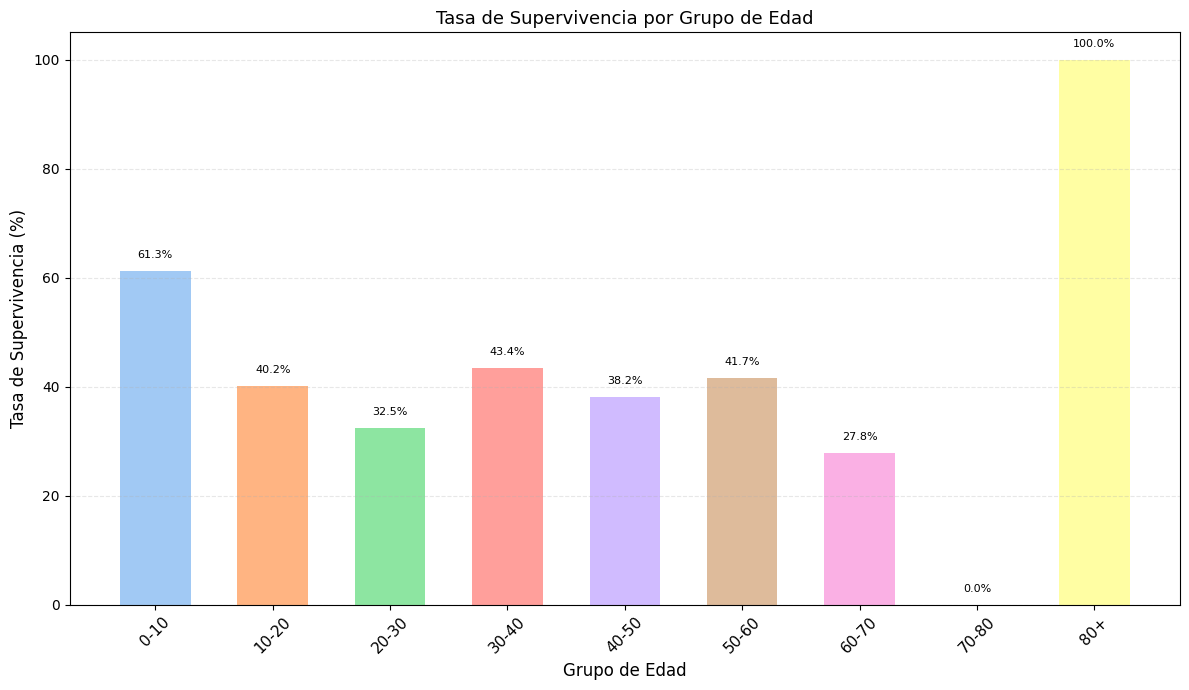

In [19]:
# Gráfico de barras para la tasa de supervivencia por grupo de edad
plt.figure(figsize=(12, 7))
survival_by_age = df.groupby('AgeGroup')['Survived'].mean().mul(100).round(1)
counts_by_age = df.groupby('AgeGroup').size()
colors = sns.color_palette('pastel', n_colors=len(survival_by_age))
plt.bar(survival_by_age.index, survival_by_age.values, color=colors, width=0.6)
plt.xticks(rotation=45, fontsize=11)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Tasa de Supervivencia (%)', fontsize=12)
plt.title('Tasa de Supervivencia por Grupo de Edad', fontsize=13)
plt.ylim(0, 105)
# Anotaciones: porcentaje sobre cada barra y tamaño de muestra debajo
for i, v in enumerate(survival_by_age.values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=8, va='bottom')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

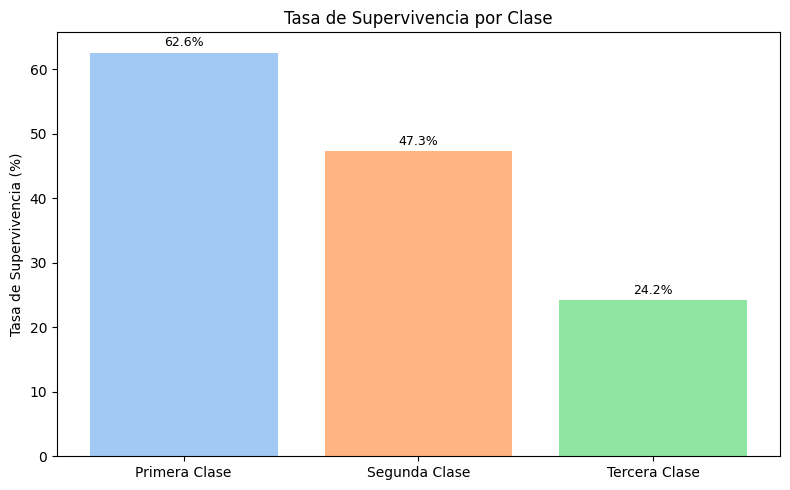

In [20]:
# Gráfico de barras para la tasa de supervivencia por clase
plt.figure(figsize=(8, 5))  # aumentamos el tamaño para evitar solapamientos
survival_by_pclass = df.groupby('Pclass')['Survived'].mean().mul(100).round(1)
colors = sns.color_palette('pastel', n_colors=len(survival_by_pclass))
plt.bar(survival_by_pclass.index, survival_by_pclass.values, color=colors)
plt.xticks([1,2,3], ['Primera Clase', 'Segunda Clase', 'Tercera Clase'])
plt.ylabel('Tasa de Supervivencia (%)')
plt.title('Tasa de Supervivencia por Clase')
# Anotaciones: porcentaje sobre cada barra y tamaño de muestra debajo
# usar las coordenadas reales de las barras en lugar de i
for i, v in enumerate(survival_by_pclass.values):
    x = survival_by_pclass.index[i]
    plt.text(x, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

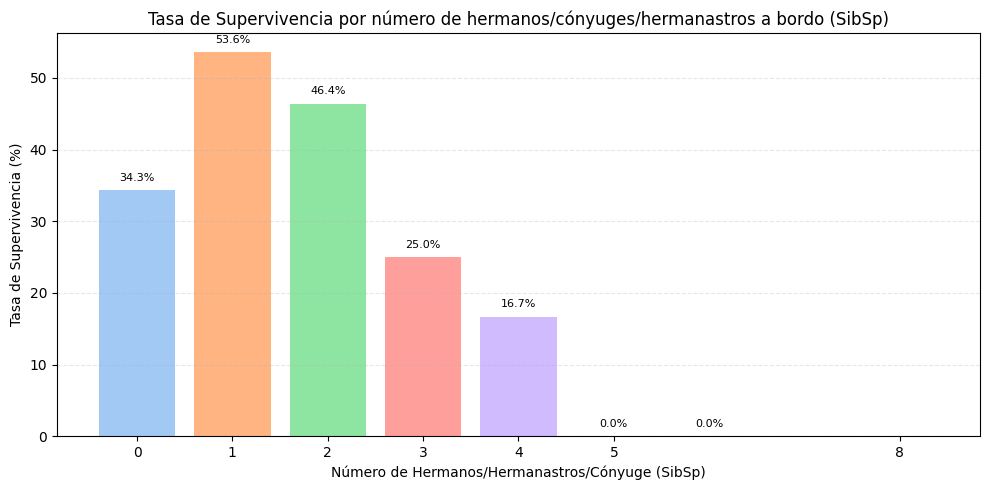

In [37]:
# Gráfico de barras para la tasa de supervivencia por SibSp (número de hermanos/cónyuges/hermanastros a bordo)
plt.figure(figsize=(10, 5))
survival_by_sibsp = df.groupby('SibSp')['Survived'].mean().mul(100).round(1)
colors = sns.color_palette('pastel', n_colors=len(survival_by_sibsp))
plt.bar(survival_by_sibsp.index, survival_by_sibsp.values, color=colors)
plt.xticks(survival_by_sibsp.index)
plt.xlabel('Número de Hermanos/Hermanastros/Cónyuge (SibSp)')
plt.ylabel('Tasa de Supervivencia (%)')
plt.title('Tasa de Supervivencia por número de hermanos/cónyuges/hermanastros a bordo (SibSp)')
for i, v in enumerate(survival_by_sibsp.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=8, va='bottom')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


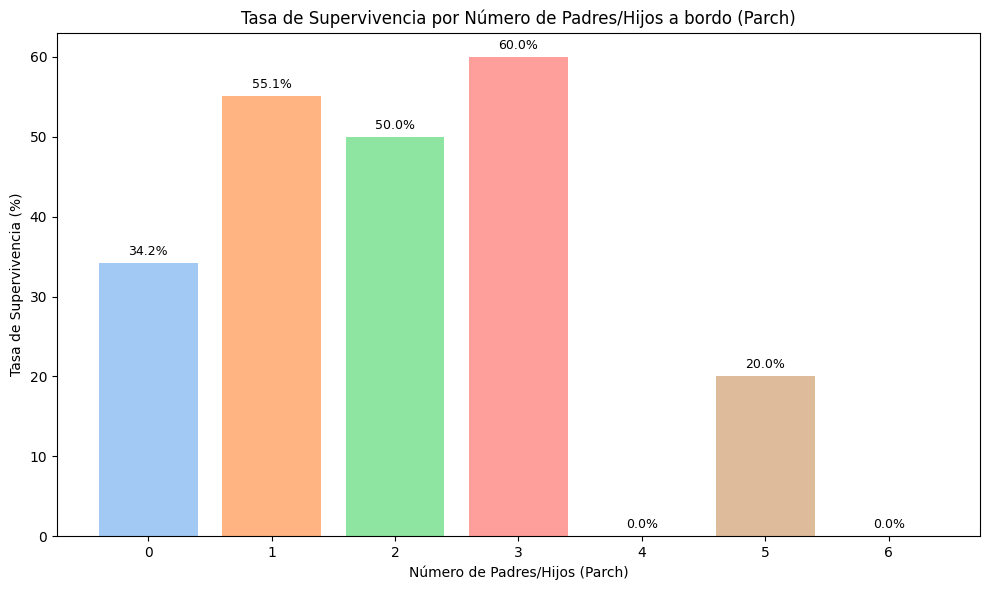

In [21]:
# Gráfico de barras para la tasa de supervivencia por número de hijos/padres a bordo (Parch)
plt.figure(figsize=(10, 6))
survival_by_parch = df.groupby('Parch')['Survived'].mean().mul(100).round(1)
colors = sns.color_palette('pastel', n_colors=len(survival_by_parch))
plt.bar(survival_by_parch.index, survival_by_parch.values, color=colors)
plt.xticks(survival_by_parch.index)
plt.xlabel('Número de Padres/Hijos (Parch)')
plt.ylabel('Tasa de Supervivencia (%)')
plt.title('Tasa de Supervivencia por Número de Padres/Hijos a bordo (Parch)')
for i, v in enumerate(survival_by_parch.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
# Pivot table: tasa de supervivencia según grupo de edad y clase
pivot_age_class = df.pivot_table(
    values='Survived',
    index='AgeGroup',
    columns='Pclass',
    aggfunc='mean'
).mul(100).round(1)
pivot_age_class.columns = ['1ª clase', '2ª clase', '3ª clase']
print("\nTasa de supervivencia (%) por grupo de edad y clase:")
print(pivot_age_class)


Tasa de supervivencia (%) por grupo de edad y clase:
          1ª clase  2ª clase  3ª clase
AgeGroup                              
0-10          66.7     100.0      45.2
10-20         83.3      50.0      25.8
20-30         59.4      40.6      24.2
30-40         77.6      39.6      21.7
40-50         59.5      55.6       5.9
50-60         55.6      33.3       0.0
60-70         25.0      33.3      33.3
70-80          0.0       0.0       0.0
80+          100.0       NaN       NaN



Mortalidad (%) de niños <10 años por clase:
Pclass
1    33.3%
2     0.0%
3    54.8%
Name: Survived, dtype: str

Cantidad de niños en cada clase:
Pclass
1     3
2    17
3    42
Name: count, dtype: int64


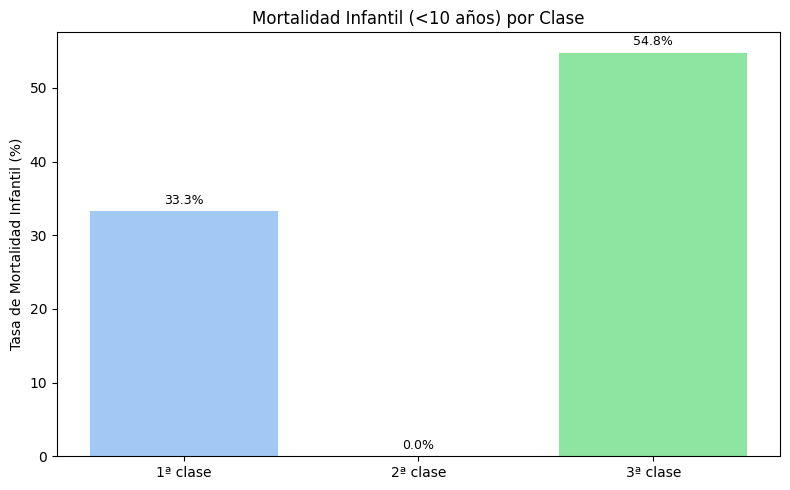

In [23]:
# Mortalidad infantil por clase (menores de 10 años)
children = df[df['Age'] < 10]
mortality_by_class = (1 - children.groupby('Pclass')['Survived'].mean()).mul(100).round(1)
counts_children = children['Pclass'].value_counts().sort_index()

print("\nMortalidad (%) de niños <10 años por clase:")
print(mortality_by_class.astype(str) + "%")
print("\nCantidad de niños en cada clase:")
print(counts_children)

plt.figure(figsize=(8,5))
colors = sns.color_palette('pastel', n_colors=len(mortality_by_class))
plt.bar(mortality_by_class.index, mortality_by_class.values, color=colors)
plt.xticks([1,2,3], ['1ª clase','2ª clase','3ª clase'])
plt.ylabel('Tasa de Mortalidad Infantil (%)')
plt.title('Mortalidad Infantil (<10 años) por Clase')
for i, v in enumerate(mortality_by_class.values):
    x = mortality_by_class.index[i]
    plt.text(x, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

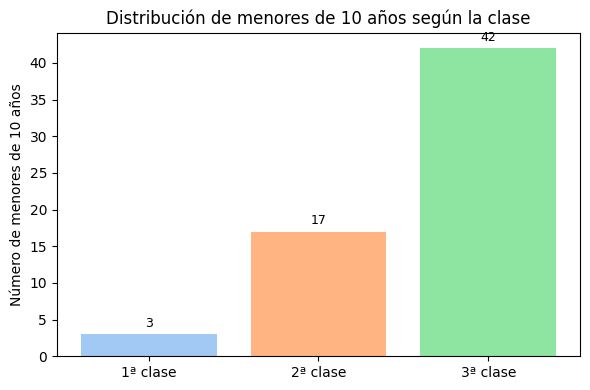

In [24]:
# Gráfico de distribución de menores de 10 años por clase
children_counts = children['Pclass'].value_counts().sort_index()
plt.figure(figsize=(6,4))
colors = sns.color_palette('pastel', n_colors=len(children_counts))
plt.bar(children_counts.index, children_counts.values, color=colors)
plt.xticks([1,2,3], ['1ª clase','2ª clase','3ª clase'])
plt.ylabel('Número de menores de 10 años')
plt.title('Distribución de menores de 10 años según la clase')
for i, v in enumerate(children_counts.values):
    plt.text(children_counts.index[i], v + 1, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [25]:
# Pivot table: tasa de supervivencia cruzada por clase y puerto
pivot_survival = df.pivot_table(
    values='Survived',
    index='Pclass',
    columns='Embarked',
    aggfunc='mean'
).mul(100).round(1)
pivot_survival.index = ['1ª clase', '2ª clase', '3ª clase']
pivot_survival.columns = ['Cherbourg', 'Queenstown', 'Southampton']
print("\nTasa de supervivencia (%) según clase y puerto de embarque:")
print(pivot_survival)

# Pivot table: número de pasajeros
pivot_count = df.pivot_table(
    values='PassengerId',
    index='Pclass',
    columns='Embarked',
    aggfunc='count'
)
pivot_count.index = ['1ª clase', '2ª clase', '3ª clase']
pivot_count.columns = ['Cherbourg', 'Queenstown', 'Southampton']
print("\nNúmero de pasajeros según clase y puerto de embarque:")
print(pivot_count)


Tasa de supervivencia (%) según clase y puerto de embarque:
          Cherbourg  Queenstown  Southampton
1ª clase       69.4        50.0         58.3
2ª clase       52.9        66.7         46.3
3ª clase       37.9        37.5         19.0

Número de pasajeros según clase y puerto de embarque:
          Cherbourg  Queenstown  Southampton
1ª clase         85           2          127
2ª clase         17           3          164
3ª clase         66          72          353



Tasa de supervivencia por puerto de embarque:
Embarked
C    55.4%
Q    39.0%
S    33.7%
Name: Survived, dtype: str

Número de pasajeros por puerto:
Embarked
C    168
Q     77
S    644
Name: count, dtype: int64


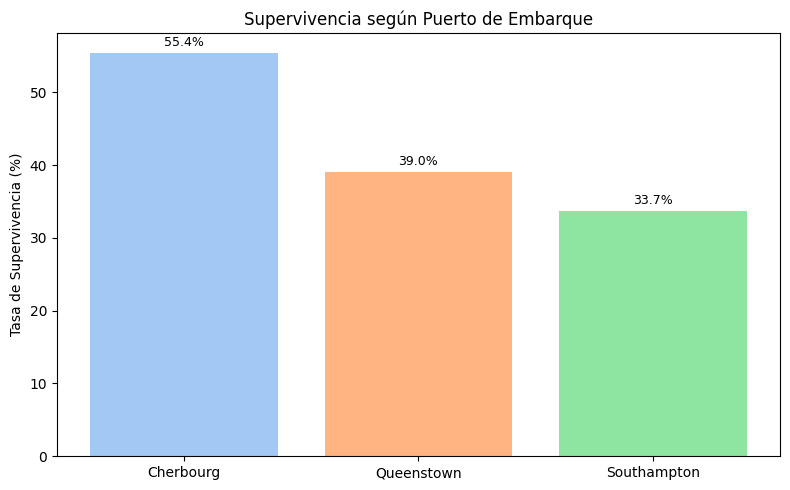

In [26]:
# Tasa de supervivencia según puerto de embarque
survival_by_embarked = df.groupby('Embarked')['Survived'].mean().mul(100).round(1)
counts_embarked = df['Embarked'].value_counts().sort_index()

print("\nTasa de supervivencia por puerto de embarque:")
print(survival_by_embarked.astype(str) + "%")
print("\nNúmero de pasajeros por puerto:")
print(counts_embarked)

plt.figure(figsize=(8,5))  # un poco más ancho para que quepan etiquetas y anotaciones
colors = sns.color_palette('pastel', n_colors=len(survival_by_embarked))
plt.bar(survival_by_embarked.index, survival_by_embarked.values, color=colors)
plt.xticks(survival_by_embarked.index, ['Cherbourg','Queenstown','Southampton'])
plt.ylabel('Tasa de Supervivencia (%)')
plt.title('Supervivencia según Puerto de Embarque')
for i, v in enumerate(survival_by_embarked.values):
    x = survival_by_embarked.index[i]
    plt.text(x, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

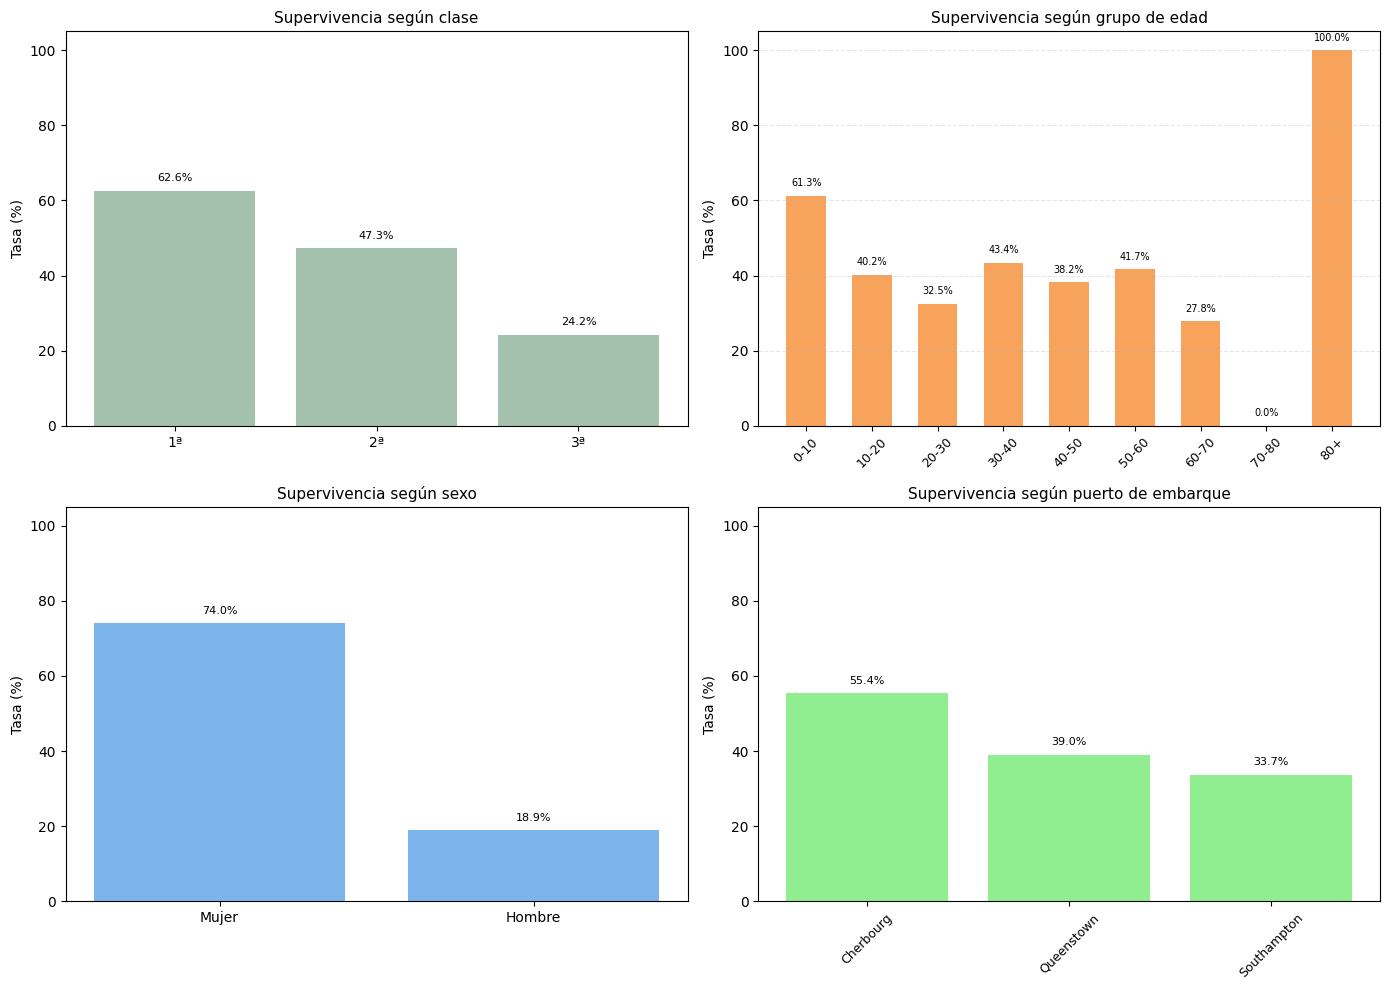

In [55]:
# Crear figura con múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']
if 'AgeGroup' not in df.columns:
    df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

survival_by_age = df.groupby('AgeGroup')['Survived'].mean().mul(100).round(1)
survival_by_pclass = df.groupby('Pclass')['Survived'].mean().mul(100).round(1)
survival_by_sex = df.groupby('Sex')['Survived'].mean().mul(100).round(1)
survival_by_embarked = df.groupby('Embarked')['Survived'].mean().mul(100).round(1)

# Conteos para anotaciones
sex_counts = df['Sex'].value_counts()

# Gráfico 1: Por Clase
axes[0, 0].bar(survival_by_pclass.index, survival_by_pclass.values, color='#a3c1ad')
axes[0, 0].set_title('Supervivencia según clase', fontsize=11)
axes[0, 0].set_ylabel('Tasa (%)', fontsize=10)
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].set_xticklabels(['1ª', '2ª', '3ª'])
axes[0, 0].set_ylim(0, 105)
for i, (idx, v) in enumerate(survival_by_pclass.items()):
    axes[0, 0].text(idx, v + 2, f"{v:.1f}%", ha='center', fontsize=8, va='bottom')

# Gráfico 2: Por Edad 
axes[0, 1].bar(range(len(survival_by_age)), survival_by_age.values, color='#f7a35c', width=0.6)
axes[0, 1].set_title('Supervivencia según grupo de edad', fontsize=11)
axes[0, 1].set_ylabel('Tasa (%)', fontsize=10)
axes[0, 1].set_xticks(range(len(survival_by_age)))
axes[0, 1].set_xticklabels(survival_by_age.index, rotation=45, fontsize=9)
axes[0, 1].set_ylim(0, 105)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(survival_by_age.values):
    axes[0, 1].text(i, v + 2, f"{v:.1f}%", ha='center',fontsize=7, va='bottom')

# Gráfico 3: Por Sexo (CORREGIDO - anotaciones y mejor etiquetado)
sex_labels_map = {'male': 'Hombre', 'female': 'Mujer', 'M': 'Hombre', 'F': 'Mujer'}
axes[1, 0].bar(range(len(survival_by_sex)), survival_by_sex.values, color='#7cb5ec')
axes[1, 0].set_title('Supervivencia según sexo', fontsize=11)
axes[1, 0].set_ylabel('Tasa (%)', fontsize=10)
axes[1, 0].set_xticks(range(len(survival_by_sex)))
axes[1, 0].set_xticklabels([sex_labels_map.get(str(idx), str(idx)) for idx in survival_by_sex.index])
axes[1, 0].set_ylim(0, 105)
for i, (sex_key, v) in enumerate(survival_by_sex.items()):
    axes[1, 0].text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=8, va='bottom')

# Gráfico 4: Por Puerto
embarked_labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
axes[1, 1].bar(range(len(survival_by_embarked)), survival_by_embarked.values, color='#90ee90')
axes[1, 1].set_title('Supervivencia según puerto de embarque', fontsize=11)
axes[1, 1].set_ylabel('Tasa (%)', fontsize=10)
axes[1, 1].set_xticks(range(len(survival_by_embarked)))
axes[1, 1].set_xticklabels([embarked_labels.get(idx, idx) for idx in survival_by_embarked.index], rotation=45, fontsize=9)
axes[1, 1].set_ylim(0, 105)
embarked_counts = df['Embarked'].value_counts()
for i, (embarked_key, v) in enumerate(survival_by_embarked.items()):
    axes[1, 1].text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=8, va='bottom')

plt.tight_layout()
plt.savefig('supervivencia_titanic.png', dpi=300, bbox_inches='tight')
plt.show()

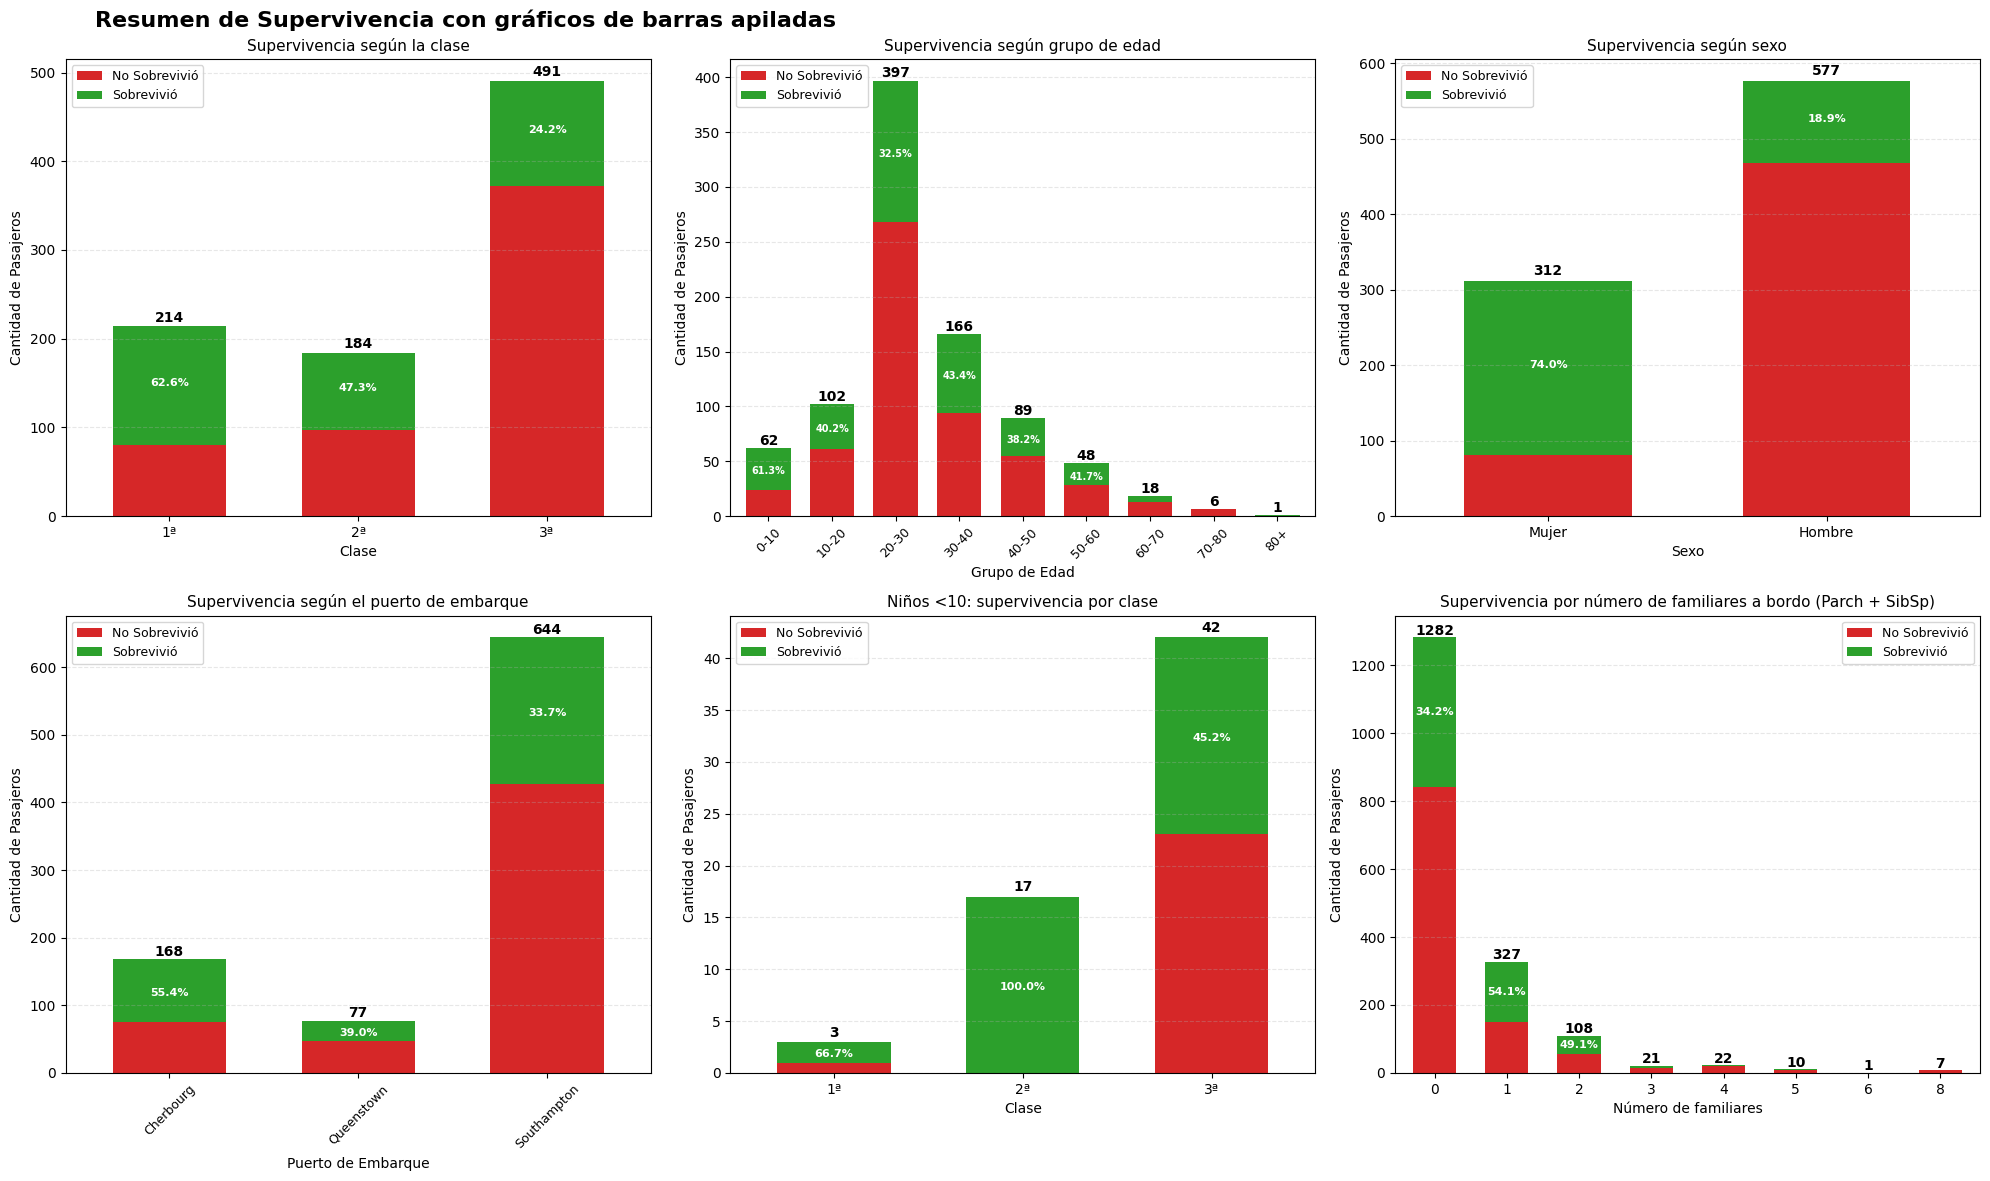

In [54]:
# Nueva figura con gráficos de barras apiladas: clase, edad, sexo, puerto y niños <10
fig, axes = plt.subplots(2, 3, figsize=(20, 12))  # 2 filas, 3 columnas

# título general arriba a la izquierda
fig.suptitle('Resumen de Supervivencia con gráficos de barras apiladas', x=0.05, y=0.98, ha='left', fontsize=16, fontweight='bold')

# Colores para supervivencia y no supervivencia
color_murio = '#d62728'  # Rojo
color_sobrevivio = '#2ca02c'  # Verde

# Gráfico 1: Barras apiladas por Clase
class_survival = pd.crosstab(df['Pclass'], df['Survived'], margins=False)
class_survival.plot(kind='bar', stacked=True, ax=axes[0,0], color=[color_murio, color_sobrevivio], width=0.6)
axes[0,0].set_title('Supervivencia según la clase', fontsize=11)
axes[0,0].set_ylabel('Cantidad de Pasajeros', fontsize=10)
axes[0,0].set_xlabel('Clase', fontsize=10)
axes[0,0].set_xticklabels(['1ª','2ª','3ª'], rotation=0)
axes[0,0].legend(['No Sobrevivió','Sobrevivió'], loc='upper left', fontsize=9)
axes[0,0].grid(axis='y', alpha=0.3, linestyle='--')
for i,(idx,row) in enumerate(class_survival.iterrows()):
    total=row.sum(); muertos=row[0]; sobrevivientes=row[1]
    pct=(sobrevivientes/total*100)
    axes[0,0].text(i,total+5,f"{int(total)}",ha='center',fontsize=10,fontweight='bold')
    axes[0,0].text(i,muertos+sobrevivientes/2,f"{pct:.1f}%",ha='center',fontsize=8,color='white',fontweight='bold')

# Gráfico 2: Barras apiladas por Grupo de Edad
age_survival = pd.crosstab(df['AgeGroup'], df['Survived'], margins=False)
age_survival.plot(kind='bar', stacked=True, ax=axes[0,1], color=[color_murio,color_sobrevivio], width=0.7)
axes[0,1].set_title('Supervivencia según grupo de edad', fontsize=11)
axes[0,1].set_ylabel('Cantidad de Pasajeros', fontsize=10)
axes[0,1].set_xlabel('Grupo de Edad', fontsize=10)
axes[0,1].set_xticklabels(age_survival.index, rotation=45, fontsize=9)
axes[0,1].legend(['No Sobrevivió','Sobrevivió'], loc='upper left', fontsize=9)
axes[0,1].grid(axis='y', alpha=0.3, linestyle='--')
for i,(idx,row) in enumerate(age_survival.iterrows()):
    total=row.sum(); muertos=row[0]; sobrevivientes=row[1]
    pct=(sobrevivientes/total*100) if total>30 else 0
    axes[0,1].text(i,total+3,f"{int(total)}",ha='center',fontsize=10,fontweight='bold')
    if sobrevivientes>0 and pct>0:
        axes[0,1].text(i,muertos+sobrevivientes/2-5,f"{pct:.1f}%",ha='center',fontsize=7,color='white',fontweight='bold')

# Gráfico 3: Barras apiladas por Sexo
sex_labels_map={'male':'Hombre','female':'Mujer','M':'Hombre','F':'Mujer'}
sex_survival=pd.crosstab(df['Sex'],df['Survived'],margins=False)
sex_survival.plot(kind='bar',stacked=True,ax=axes[0,2],color=[color_murio,color_sobrevivio],width=0.6)
axes[0,2].set_title('Supervivencia según sexo',fontsize=11)
axes[0,2].set_ylabel('Cantidad de Pasajeros',fontsize=10)
axes[0,2].set_xlabel('Sexo',fontsize=10)
axes[0,2].set_xticklabels([sex_labels_map.get(str(idx),str(idx)) for idx in sex_survival.index],rotation=0)
axes[0,2].legend(['No Sobrevivió','Sobrevivió'],loc='upper left',fontsize=9)
axes[0,2].grid(axis='y',alpha=0.3,linestyle='--')
for i,(idx,row) in enumerate(sex_survival.iterrows()):
    total=row.sum(); muertos=row[0]; sobrevivientes=row[1]
    pct=(sobrevivientes/total*100)
    axes[0,2].text(i,total+8,f"{int(total)}",ha='center',fontsize=10,fontweight='bold')
    axes[0,2].text(i,muertos+sobrevivientes/2,f"{pct:.1f}%",ha='center',fontsize=8,color='white',fontweight='bold')

# Gráfico 4: Barras apiladas por Puerto
embarked_labels={'C':'Cherbourg','Q':'Queenstown','S':'Southampton'}
embarked_survival=pd.crosstab(df['Embarked'],df['Survived'],margins=False)
embarked_survival.plot(kind='bar',stacked=True,ax=axes[1,0],color=[color_murio,color_sobrevivio],width=0.6)
axes[1,0].set_title('Supervivencia según el puerto de embarque',fontsize=11)
axes[1,0].set_ylabel('Cantidad de Pasajeros',fontsize=10)
axes[1,0].set_xlabel('Puerto de Embarque',fontsize=10)
axes[1,0].set_xticklabels([embarked_labels.get(idx,idx) for idx in embarked_survival.index],rotation=45,fontsize=9)
axes[1,0].legend(['No Sobrevivió','Sobrevivió'],loc='upper left',fontsize=9)
axes[1,0].grid(axis='y',alpha=0.3,linestyle='--')
for i,(idx,row) in enumerate(embarked_survival.iterrows()):
    total=row.sum(); muertos=row[0]; sobrevivientes=row[1]
    pct=(sobrevivientes/total*100)
    axes[1,0].text(i,total+5,f"{int(total)}",ha='center',fontsize=10,fontweight='bold')
    axes[1,0].text(i,muertos+sobrevivientes/2-8,f"{pct:.1f}%",ha='center',fontsize=8,color='white',fontweight='bold')

# Gráfico 5: Niños <10 supervivencia por clase
children=df[df['Age']<10]
child_survival=pd.crosstab(children['Pclass'],children['Survived'],margins=False)
child_survival.plot(kind='bar',stacked=True,ax=axes[1,1],color=[color_murio,color_sobrevivio],width=0.6)
axes[1,1].set_title('Niños <10: supervivencia por clase',fontsize=11)
axes[1,1].set_ylabel('Cantidad de Pasajeros',fontsize=10)
axes[1,1].set_xlabel('Clase',fontsize=10)
axes[1,1].set_xticklabels(['1ª','2ª','3ª'],rotation=0)
axes[1,1].legend(['No Sobrevivió','Sobrevivió'],loc='upper left',fontsize=9)
axes[1,1].grid(axis='y',alpha=0.3,linestyle='--')
for i,(idx,row) in enumerate(child_survival.iterrows()):
    total=row.sum(); muertos=row[0]; sobrevivientes=row[1]
    pct=(sobrevivientes/total*100) if total>0 else 0
    axes[1,1].text(i,total+0.5,f"{int(total)}",ha='center',fontsize=10,fontweight='bold')
    axes[1,1].text(i,muertos+sobrevivientes/2-0.5,f"{pct:.1f}%",ha='center',fontsize=8,color='white',fontweight='bold')

# Gráfico 6: Supervivencia por número de familiares a bordo (Parch + SibSp)
parch_survival=pd.crosstab(df['Parch'],df['Survived'],margins=False)
sibsp_survival=pd.crosstab(df['SibSp'],df['Survived'],margins=False)
family_survival=parch_survival.add(sibsp_survival, fill_value=0)
family_survival.plot(kind='bar',stacked=True,ax=axes[1,2],color=[color_murio,color_sobrevivio],width=0.6)
axes[1,2].set_title('Supervivencia por número de familiares a bordo (Parch + SibSp)',fontsize=11)
axes[1,2].set_ylabel('Cantidad de Pasajeros',fontsize=10)
axes[1,2].set_xlabel('Número de familiares',fontsize=10)
axes[1,2].set_xticks(range(len(family_survival.index)))
axes[1,2].set_xticklabels(family_survival.index, rotation=0)
axes[1,2].legend(['No Sobrevivió','Sobrevivió'],loc='upper right',fontsize=9)
axes[1,2].grid(axis='y',alpha=0.3,linestyle='--')
for i,(idx,row) in enumerate(family_survival.iterrows()):
    total=row.sum(); muertos=row[0]; sobrevivientes=row[1]
    pct=(sobrevivientes/total*100) if total>50 else 0
    axes[1,2].text(i,total+8,f"{int(total)}",ha='center',fontsize=10,fontweight='bold')
    if sobrevivientes>0 and pct>0:
        axes[1,2].text(i,muertos+sobrevivientes/2-8,f"{pct:.1f}%",ha='center',fontsize=8,color='white',fontweight='bold')




plt.tight_layout()

plt.savefig('supervivencia_titanic_barras_apiladas.png', dpi=300, bbox_inches='tight')
plt.show()

# Conclusiones

- La tasa de supervivencia general fue del 38.2 %.
- Las mujeres y los niños tenían mayor probabilidad de salvarse; en los gráficos se aprecia claramente el efecto de “first women and children”.
- Viajar en primera clase daba ventaja: el porcentaje de supervivientes decae con la clase (1 > 2 > 3).
- Los grupos de edad muestran que los más jóvenes presentan tasas más altas de supervivencia.
- Los niños menores de 10 años pertenecientes a la tercera clase tenían menos probabilidad de sobrevivir que los pertenecientes a las otras dos clases.
- Las personas pertenecientes a familias con un número de miembros entre 1 y 2 tuvieron más probabilidad de sobrevivir que las más o menos numerosas. 
- A pesar de que más personas embarcaron en Southampton respecto a los otros dos puertos, presentan una menor tasa de supervivencia, sobre todo comparando con el puerto de Cherbourg. En este puerto hubo en proporción más embarcados pertenecientes a la primera clase.

> 📌 En conjunto, los gráficos confirman que el estatus socio‑económico (clase), el género y la edad fueron los factores más determinantes a la hora de sobrevivir al hundimiento del Titanic. Las distribuciones de sexo, clase, número de familiares y puerto de embarque muestran sesgos demográficos en los que viajaban en el Titanic: más hombres, muchos en 3ª clase, pocos con familias grandes y predominio de embarque en Southampton.